Total panel-level evaluations : 1311
Non-flagged figures           : 40
Panels per model:
 model
gemini_3.5_flash_outputs         222
gpt54nano_outputs                222
DeepSeek_V4_Flash_outputs        222
gpt54minioutputs                 221
mistral_large_3_outputs          218
gemini_3.1_flash_lite_outputs    206
Name: count, dtype: int64 

FOR THE PAPER (point estimate [95% Wilson CI])
Gemini 3.5 Flash       (n=222)
   Caption good :  88.3% [83.4, 91.9]
   Summary good :  87.4% [82.4, 91.1]
   Hallucination:   9.0% [5.9, 13.5]

Gemini 3.1 Flash Lite  (n=206)
   Caption good :  82.0% [76.2, 86.7]
   Summary good :  83.5% [77.8, 87.9]
   Hallucination:   4.8% [2.7, 8.7]

GPT-5.4 Nano           (n=222)
   Caption good :  56.8% [50.2, 63.1]
   Summary good :  53.1% [46.6, 59.6]
   Hallucination:  23.9% [18.7, 29.9]

GPT-5.4 Mini           (n=221)
   Caption good :  58.8% [52.2, 65.1]
   Summary good :  52.0% [45.5, 58.5]
   Hallucination:  15.4% [11.2, 20.7]

DeepSeek V4 Flash      (n

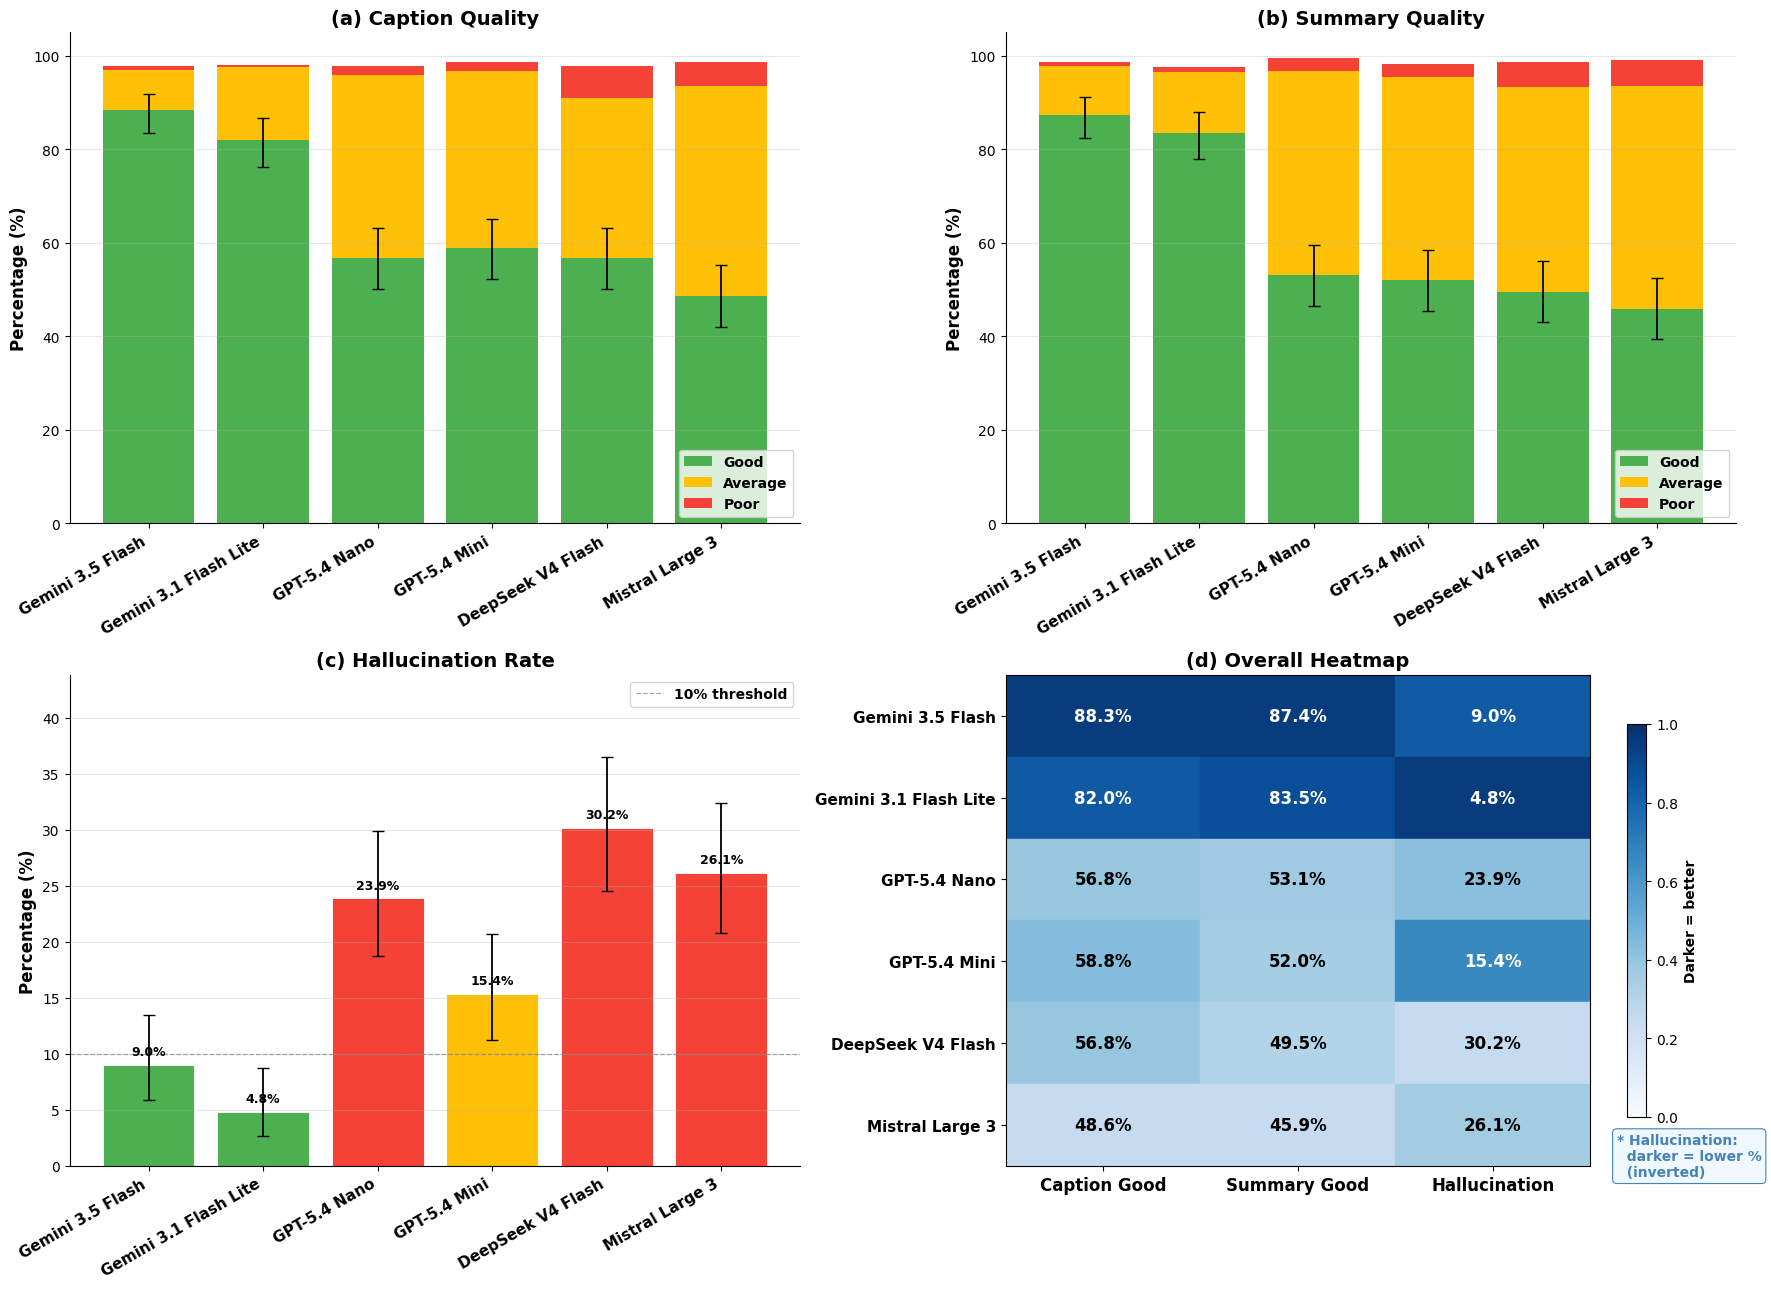

Saved: model_performance_caption.pdf  and  model_performance_non_flagged.csv


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# ============================================================
# SETTINGS
# ============================================================
json_path = "benchmark_results_cap_sum.json"

name_map = {
    "gemini_3.5_flash_outputs":      "Gemini 3.5 Flash",
    "gemini_3.1_flash_lite_outputs": "Gemini 3.1 Flash Lite",
    "gpt54nano_outputs":             "GPT-5.4 Nano",
    "gpt54minioutputs":              "GPT-5.4 Mini",
    "DeepSeek_V4_Flash_outputs":     "DeepSeek V4 Flash",
    "mistral_large_3_outputs":       "Mistral Large 3",
}

# ============================================================
# LOAD + FLATTEN  (skip flagged; missing hallucination -> "missing")
# ============================================================
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for image_id, image_data in data.items():
    if image_data.get("flagged", False):
        continue
    sb = image_data.get("summary_benchmark", {})
    for model, outputs in sb.items():
        for panel, m in outputs.items():
            rows.append({
                "image_id": image_id,
                "model": model,
                "panel": panel,
                "caption_quality": m.get("subcaption_quality"),
                "summary_quality": m.get("summary_quality"),
                "hallucination": m.get("hallucination", "missing"),
            })

df = pd.DataFrame(rows)
print("Total panel-level evaluations :", len(df))
print("Non-flagged figures           :", df["image_id"].nunique())
print("Panels per model:\n", df["model"].value_counts(), "\n")

# ============================================================
# WILSON HELPER
# ============================================================
def wilson(k, n):
    if n == 0:
        return 0.0, 0.0, 0.0
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    return 100*k/n, 100*lo, 100*hi

# ============================================================
# BUILD RESULTS TABLE (denominator = all panels for that model)
# ============================================================
results = []
for model in df["model"].unique():
    t = df[df["model"] == model]
    n = len(t)

    cg, cg_lo, cg_hi = wilson((t.caption_quality == "good").sum(), n)
    sg, sg_lo, sg_hi = wilson((t.summary_quality == "good").sum(), n)
    h,  h_lo,  h_hi  = wilson((t.hallucination   == "yes").sum(),  n)

    results.append({
        "Model": name_map.get(model, model),
        "N": n,
        "Caption Good %":    round((t.caption_quality == "good").mean()*100, 2),
        "Caption Average %": round((t.caption_quality == "average").mean()*100, 2),
        "Caption Poor %":    round((t.caption_quality == "poor").mean()*100, 2),
        "Summary Good %":    round((t.summary_quality == "good").mean()*100, 2),
        "Summary Average %": round((t.summary_quality == "average").mean()*100, 2),
        "Summary Poor %":    round((t.summary_quality == "poor").mean()*100, 2),
        "Hallucination %":   round((t.hallucination == "yes").mean()*100, 2),
        "Cap CI lo": cg_lo, "Cap CI hi": cg_hi,
        "Sum CI lo": sg_lo, "Sum CI hi": sg_hi,
        "Hall CI lo": h_lo, "Hall CI hi": h_hi,
    })

perf = pd.DataFrame(results).sort_values("Summary Good %", ascending=False).reset_index(drop=True)
perf.to_csv("model_performance_non_flagged.csv", index=False)

# ---- Pretty print for the paper prose ----
print("="*78)
print("FOR THE PAPER (point estimate [95% Wilson CI])")
print("="*78)
for _, r in perf.iterrows():
    print(f"{r['Model']:22} (n={int(r['N'])})")
    print(f"   Caption good : {r['Caption Good %']:5.1f}% [{r['Cap CI lo']:.1f}, {r['Cap CI hi']:.1f}]")
    print(f"   Summary good : {r['Summary Good %']:5.1f}% [{r['Sum CI lo']:.1f}, {r['Sum CI hi']:.1f}]")
    print(f"   Hallucination: {r['Hallucination %']:5.1f}% [{r['Hall CI lo']:.1f}, {r['Hall CI hi']:.1f}]")
    print()

# ============================================================
# FIGURE  (2x2) WITH WILSON ERROR BARS
# ============================================================
models = perf["Model"].tolist()
x = np.arange(len(models))
colors = {"Good": "#4CAF50", "Average": "#FFC107", "Poor": "#F44336"}

def err(series_pct, lo, hi):
    """asymmetric yerr arrays for matplotlib from pct point + CI bounds"""
    lower = series_pct - lo
    upper = hi - series_pct
    return np.vstack([lower, upper])

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# (a) Caption stacked + CI on the 'good' segment
ax = axes[0, 0]
ax.bar(x, perf["Caption Good %"], color=colors["Good"], label="Good")
ax.bar(x, perf["Caption Average %"], bottom=perf["Caption Good %"], color=colors["Average"], label="Average")
ax.bar(x, perf["Caption Poor %"],
       bottom=perf["Caption Good %"] + perf["Caption Average %"], color=colors["Poor"], label="Poor")
ax.errorbar(x, perf["Caption Good %"],
            yerr=err(perf["Caption Good %"], perf["Cap CI lo"], perf["Cap CI hi"]),
            fmt="none", ecolor="black", elinewidth=1.3, capsize=4)
ax.set_title("(a) Caption Quality", fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha="right", fontsize=11, fontweight="bold")
ax.set_ylim(0, 105); ax.legend(loc="lower right", prop={"weight": "bold"}); ax.grid(axis="y", alpha=0.3)
for s in ["top", "right"]: ax.spines[s].set_visible(False)

# (b) Summary stacked + CI on the 'good' segment
ax = axes[0, 1]
ax.bar(x, perf["Summary Good %"], color=colors["Good"], label="Good")
ax.bar(x, perf["Summary Average %"], bottom=perf["Summary Good %"], color=colors["Average"], label="Average")
ax.bar(x, perf["Summary Poor %"],
       bottom=perf["Summary Good %"] + perf["Summary Average %"], color=colors["Poor"], label="Poor")
ax.errorbar(x, perf["Summary Good %"],
            yerr=err(perf["Summary Good %"], perf["Sum CI lo"], perf["Sum CI hi"]),
            fmt="none", ecolor="black", elinewidth=1.3, capsize=4)
ax.set_title("(b) Summary Quality", fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha="right", fontsize=11, fontweight="bold")
ax.set_ylim(0, 105); ax.legend(loc="lower right", prop={"weight": "bold"}); ax.grid(axis="y", alpha=0.3)
for s in ["top", "right"]: ax.spines[s].set_visible(False)

# (c) Hallucination + CI
ax = axes[1, 0]
bar_colors = ["#4CAF50" if v <= 10 else "#FFC107" if v <= 20 else "#F44336" for v in perf["Hallucination %"]]
bars = ax.bar(x, perf["Hallucination %"], color=bar_colors, edgecolor="white", linewidth=0.6)
ax.errorbar(x, perf["Hallucination %"],
            yerr=err(perf["Hallucination %"], perf["Hall CI lo"], perf["Hall CI hi"]),
            fmt="none", ecolor="black", elinewidth=1.3, capsize=4)
ax.set_title("(c) Hallucination Rate", fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha="right", fontsize=11, fontweight="bold")
ax.set_ylim(0, perf["Hall CI hi"].max() * 1.20)
ax.axhline(10, color="gray", linestyle="--", linewidth=0.9, alpha=0.7, label="10% threshold")
ax.legend(loc="upper right", prop={"weight": "bold"}); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, perf["Hallucination %"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
for s in ["top", "right"]: ax.spines[s].set_visible(False)

# (d) Heatmap (Caption Good, Summary Good, Hallucination)
ax = axes[1, 1]
cols = ["Caption Good %", "Summary Good %", "Hallucination %"]
labels = ["Caption Good", "Summary Good", "Hallucination"]
heat = perf[cols].values
score = np.zeros_like(heat, dtype=float)
for j in range(heat.shape[1]):
    col = heat[:, j]; lo, hi = col.min(), col.max()
    norm = (col - lo) / (hi - lo + 1e-9)
    score[:, j] = norm if j < 2 else (1 - norm)  # invert hallucination
blues = plt.cm.Blues
for i in range(len(models)):
    for j in range(len(cols)):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=blues(0.25 + score[i, j]*0.7)))
        tc = "white" if score[i, j] > 0.55 else "black"
        ax.text(j, i, f"{heat[i, j]:.1f}%", ha="center", va="center",
                fontsize=12, fontweight="bold", color=tc)
ax.set_xlim(-0.5, len(cols)-0.5); ax.set_ylim(-0.5, len(models)-0.5)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=12, fontweight="bold")
ax.set_yticks(range(len(models))); ax.set_yticklabels(models, fontsize=11, fontweight="bold")
ax.set_title("(d) Overall Heatmap", fontsize=14, fontweight="bold"); ax.invert_yaxis()
sm = plt.cm.ScalarMappable(cmap=blues, norm=plt.Normalize(0, 1)); sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label("Darker = better", fontsize=10, fontweight="bold")
cbar.ax.text(-0.5, -0.1, "* Hallucination:\n  darker = lower %\n  (inverted)",
             transform=cbar.ax.transAxes, fontsize=10, fontweight="bold",color="steelblue",
             va="center", ha="left",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="aliceblue", edgecolor="steelblue", lw=0.8))

plt.tight_layout()
plt.savefig("model_performance_caption.pdf", bbox_inches="tight")
plt.show()
print("Saved: model_performance_caption.pdf  and  model_performance_non_flagged.csv")

In [2]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.6 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 29.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 25.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [s